# Kaggriculture: rank your agent against a known ladder

[Kaggriculture](https://www.kaggle.com/competitions/kaggriculture) scores you on
**head-to-head wins**, not on an absolute metric. That makes progress genuinely hard
to read. Your agent banked 40,000 coins — is that good? It depends entirely on who it
played. Beating the built-in `starter` baseline tells you almost nothing, and the
public leaderboard only updates after you have spent a submission.

So I built a fixed ladder to measure against. This notebook:

1. loads **ten documented reference agents** spanning a very wide skill range, plus the
   top-meta agent that beats all ten of them,
2. lets you plug in **your own agent** three different ways,
3. plays a seat-swapped round robin and ranks everyone with **Bradley-Terry** —
   the same method the competition uses for final standings,
4. tells you which rung you landed on,
5. and writes a **submittable `submission.tar.gz`**, so the agent you ranked is
   literally the artifact you submit.

The whole default run takes a couple of minutes. There is a knob at the bottom for a
much heavier evaluation when you want tighter error bars.

> **What you need:** the
> [Kaggriculture Reference Agents](https://www.kaggle.com/datasets/raykkretzschmar/kaggriculture-reference-agents)
> dataset attached (Add Input → Datasets), the output of
> [Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta)
> attached (Add Input → Notebook Output) for the rung above the ladder, and
> **Internet on** so the notebook can install a matching `kaggle-environments`.


---
## 1. Setup

One thing worth being fussy about: **pin the engine version**, and then *verify the pin
actually took*.

This is not a formality. The same game on the same seed can pay out very differently
across releases. Every number in the current reference dataset was measured on
**1.32.7**, and the check below confirms that by replaying a game straight out of
`head_to_head_games.csv` and requiring it to reproduce to the coin.

Worse, checking the version string is not enough. `importlib.metadata.version()` reads
the *newly written* package metadata, while `import kaggle_environments` can still
resolve to an older copy earlier on `sys.path` — so a pip install reports success, the
version check passes, and the engine you are actually running is the old one. I lost
several hours to exactly that, comparing measurements taken on three different engines
without realising it.

So the cell below installs the pin, then **replays a game from the dataset and asserts
the bank matches**. A behavioural fixture cannot be fooled by a stale import.


In [1]:
import subprocess, sys
from importlib.metadata import PackageNotFoundError, version as pkg_version

ENGINE_VERSION = "1.32.7"   # the version these reference agents were measured on


def installed_engine():
    try:
        return pkg_version("kaggle-environments")
    except PackageNotFoundError:
        return None


def ensure_engine(want=ENGINE_VERSION):
    have = installed_engine()
    if have != want:
        print(f"installing kaggle-environments=={want} (found: {have})")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", f"kaggle-environments=={want}"],
            check=False,
        )
        for mod in [m for m in list(sys.modules) if m.startswith("kaggle_environments")]:
            del sys.modules[mod]
        have = installed_engine()
    return have


actual = ensure_engine()
print("kaggle-environments (reported):", actual)

from kaggle_environments import make
make("kaggriculture", configuration={"episodeSteps": 24})
print("kaggriculture environment loads OK")


installing kaggle-environments==1.32.7 (found: 1.29.3)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 62.0 MB/s eta 0:00:00
kaggle-environments (reported): 1.32.7
kaggriculture environment loads OK


In [2]:
import importlib.util, itertools, json, math, os, shutil, sys, tarfile, time, zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

def find_dataset():
    """Locate the reference-agent dataset.

    Prefers the canonical mount, but falls back to scanning /kaggle/input for the
    manifest so a renamed or forked copy still works.
    """
    root = Path("/kaggle/input")
    # Kaggle has two input layouts depending on the image: the older flat
    # /kaggle/input/SLUG and the newer /kaggle/input/datasets/OWNER/SLUG.
    # Try both, then fall back to searching for the manifest.
    for candidate in (root / "kaggriculture-reference-agents", root / "datasets" / "raykkretzschmar/kaggriculture-reference-agents"):
        if (candidate / "agents_manifest.csv").exists():
            return candidate
    for hit in sorted(root.rglob("agents_manifest.csv")):
        return hit.parent
    raise SystemExit(
        "Reference-agent dataset not attached.\n"
        "Add Input -> Datasets -> search 'Kaggriculture Reference Agents', then re-run."
    )


DATASET_DIR = find_dataset()
print("dataset:", DATASET_DIR)
print("contents:", sorted(p.name for p in DATASET_DIR.iterdir()))


dataset: /kaggle/input/datasets/raykkretzschmar/kaggriculture-reference-agents
contents: ['LICENSE', 'NOTICE', 'agents_manifest.csv', 'baseline_league.csv', 'broker_bea.py', 'closer_cleo.py', 'crop_economics.csv', 'fallow_finn.py', 'head_to_head_games.csv', 'homestead_hana.py', 'ledger_lena.py', 'melon_mateo.py', 'price_curves.csv', 'rancher_rita.py', 'rotation_rosa.py', 'season_timeline.csv', 'slotter_silas.py', 'wheat_walter.py']


In [3]:
# Behavioural engine check. The version string can lie -- a pip install writes new
# package metadata while `import kaggle_environments` may still resolve to an older copy
# earlier on sys.path. So replay a real game out of the dataset and require the banks to
# match. Expected values are read from the CSV, so this stays correct if the dataset is
# ever re-measured.
def _fixture_agent(path, name):
    spec = importlib.util.spec_from_file_location(f"fixture_{name}", path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.agent


def verify_engine_behaviour():
    """Replay one recorded pairing; return (ok, detail)."""
    games = pd.read_csv(DATASET_DIR / "head_to_head_games.csv")
    row = games.iloc[0]
    a = _fixture_agent(DATASET_DIR / f"{row.agent_a}.py", "a")
    b = _fixture_agent(DATASET_DIR / f"{row.agent_b}.py", "b")
    seat = int(row.seat_of_a)
    pair = [a, b] if seat == 0 else [b, a]
    env = make("kaggriculture",
               configuration={"episodeSteps": 720, "seed": int(row.seed)}, debug=False)
    env.run(pair)
    rewards = [step.reward for step in env.steps[-1]]
    got_a, got_b = round(rewards[seat]), round(rewards[1 - seat])
    ok = (got_a == int(row.bank_a)) and (got_b == int(row.bank_b))
    return ok, (f"{row.agent_a} vs {row.agent_b}, seed {row.seed}, seat {seat}: "
                f"expected {int(row.bank_a):,}/{int(row.bank_b):,}, got {got_a:,}/{got_b:,}")


_ok, _detail = verify_engine_behaviour()
print(("PASS  " if _ok else "FAIL  ") + _detail)
if not _ok:
    raise SystemExit(
        "The engine is not behaving like the one the dataset was measured on "
        f"({ENGINE_VERSION}), whatever version string it reports.\n"
        "Every bank, margin and expected_bank below would be measured in a different "
        "game than the one documented. Restart the session after installing "
        f"kaggle-environments=={ENGINE_VERSION}, or re-measure the ladder yourself."
    )


PASS  fallow_finn vs wheat_walter, seed 7000, seat 0: expected 3,000/6,694, got 3,000/6,694


---
## 2. Meet the opponents

Ten agents in two bands, and they isolate different variables.

**Tiers 0–5 — authored.** Written from scratch, all sharing a **byte-identical action
scheduler**; the only difference between them is a `POLICY` dict at the top of each
file. That is deliberate: any gap in results comes from *economic decisions* alone, not
from one agent having better pathfinding than another. Diff two of these and the diff
is the lesson.

**Tiers 6–9 — the shared meta line.** These hold the opposite variable constant. All
four run the *same* production plan — the public meta line that shows up identically
across large groups of unrelated teams in public replays — and differ only in their
**market layer**: what to sell, in what order, and when to hold. Their head-to-head
ordering differs from their standalone bank ordering.

Together: tiers 0–5 teach you how to build a farm, tiers 6–9 show you that once
everyone builds the same farm, selling is the whole game. Expect a large jump between
the two bands — tier 5 banks ~46k, while the meta band banks ~149k–165k.


In [4]:
manifest = pd.read_csv(DATASET_DIR / "agents_manifest.csv").sort_values("tier")
manifest[["tier", "agent_name", "headline", "expected_bank",
          "hands", "extra_quadrants", "crops", "animals"]].to_string(index=False)


' tier     agent_name                                                       headline  expected_bank  hands  extra_quadrants               crops   animals\n    0    Fallow Finn                       Never plants anything. The reward floor.           3000    0.0              0.0                none      none\n    1   Wheat Walter                    One farmer, wheat only, harvests too early.           7056    0.0              0.0               WHEAT      none\n    2  Rotation Rosa                     Hires help and runs a three-crop rotation.          12929    4.0              0.0 WHEAT|CARROT|TOMATO      none\n    3 Homestead Hana         Buys one quadrant and scales staples with a real crew.          16030    8.0              1.0 CARROT|WHEAT|TOMATO      none\n    4    Melon Mateo                 Farms the premium crop and refuses to dump it.          28349    6.0              1.0         MELON|WHEAT      none\n    5   Rancher Rita         Livestock at scale, on the back of a wheat fee

In [5]:
for _, row in manifest.iterrows():
    print(f"--- tier {row.tier}: {row.agent_name} " + "-" * (52 - len(str(row.agent_name))))
    print("  strategy:", row.strategy)
    print("  lesson  :", row.lesson)
    print()


--- tier 0: Fallow Finn -----------------------------------------
  strategy: Returns PASS on every one of the 720 turns and issues no market orders, so the farm ends the season exactly as it started.
  lesson  : Fixes the bottom of the scale. Any agent that cannot beat Finn is losing money somewhere -- usually by buying seeds or livestock it then fails to water or feed.

--- tier 1: Wheat Walter ----------------------------------------
  strategy: Buys wheat seed, plants it in the starting NW quadrant, waters what he can reach and harvests the instant the crop is legal to harvest on day 2. Hires nobody and never buys land.
  lesson  : Two beginner mistakes, isolated. Harvesting at first_yield_day instead of max_yield_day throws away the watering bonus window: wheat taken on day 2 yields 1 unit where day 4 yields 4. And one farmer has only 24 actions a day, so most of the 25 starting tiles sit idle all season.

--- tier 2: Rotation Rosa ---------------------------------------
  strateg

---
## 3. Why the top tiers do what they do

Before ranking anything, look at this table. It is the single most useful thing I
worked out about this game, and it explains the whole top half of the ladder.

Every product has an independent **glut curve**. Sell into the market and the price
drops — but *how fast* varies enormously. The `units_until_price_floor` column is the
punchline: it is how many units you can sell before that product is worth $1.


In [6]:
curves = pd.read_csv(DATASET_DIR / "price_curves.csv")
curves.sort_values("base_price", ascending=False).to_string(index=False)


'   product  base_price  anchor_throughput_T glut_shape  glut_target scarcity_shape  scarcity_target  price_at_50_sold  price_at_150_sold  price_at_400_sold  price_at_1000_sold units_until_price_floor\n     MELON         250                  300         sq          3.6            log              0.2               225                 25                  1                   1                     158\n      WOOL         200                  105         sq          3.2            log              0.2                55                  1                  1                   1                      59\n      MILK         160                  122     linear          1.6           sqrt              0.6                55                  1                  1                   1                      76\nSTRAWBERRY         120                  100     linear          1.6           sqrt              0.7                24                  1                  1                   1                    

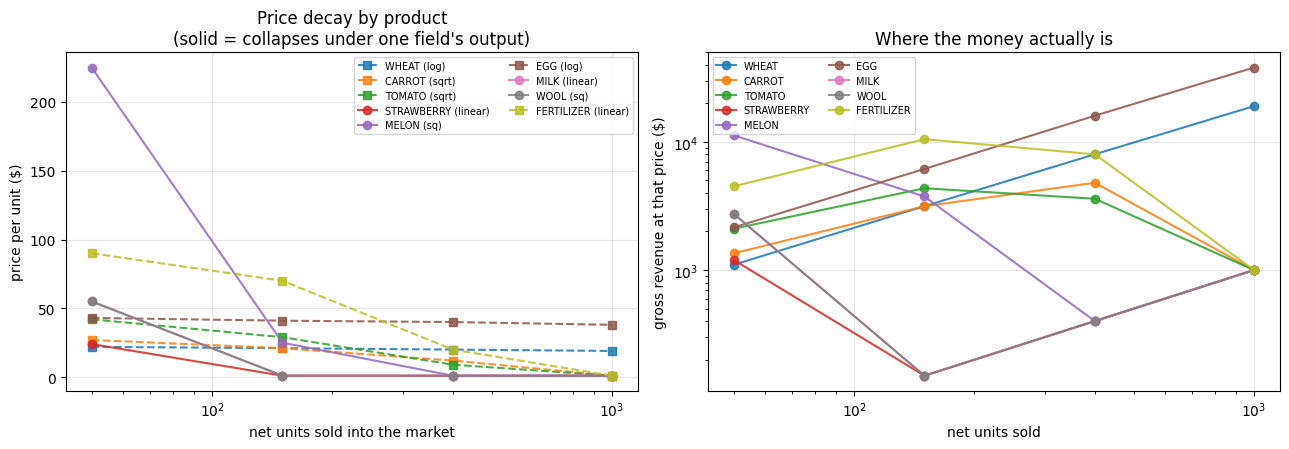

In [7]:
# Same thing as a picture: revenue you can actually extract per product.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

sold = [50, 150, 400, 1000]
for _, r in curves.iterrows():
    prices = [r.price_at_50_sold, r.price_at_150_sold,
              r.price_at_400_sold, r.price_at_1000_sold]
    style = "-o" if r.glut_target >= 1.0 else "--s"
    ax1.plot(sold, prices, style, label=f"{r['product']} ({r.glut_shape})", alpha=.85)
ax1.set_xscale("log")
ax1.set_xlabel("net units sold into the market")
ax1.set_ylabel("price per unit ($)")
ax1.set_title("Price decay by product\n(solid = collapses under one field's output)")
ax1.legend(fontsize=7, ncol=2)
ax1.grid(alpha=.3)

# Cumulative revenue if you sold N units, at the price after N units.
for _, r in curves.iterrows():
    rev = [n * p for n, p in zip(sold, [r.price_at_50_sold, r.price_at_150_sold,
                                        r.price_at_400_sold, r.price_at_1000_sold])]
    ax2.plot(sold, rev, "-o", label=r["product"], alpha=.85)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("net units sold")
ax2.set_ylabel("gross revenue at that price ($)")
ax2.set_title("Where the money actually is")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()


Read that chart and the ladder stops looking arbitrary:

- **MELON** grosses ~115 per tile per day, about five times wheat — but its glut curve
  is *quadratic* (`above_target` 3.60), so the market absorbs only ~150 melons before
  the price floors. That is why **Melon Mateo** meters his sales into 12-unit lots and
  holds a price floor, and why buying more land does *not* help him.
- **MILK** and **WOOL** floor almost as fast. **Rancher Rita** still wins with them,
  because livestock earns far more *per action* than crops once `CARE` is running.
- **WHEAT** and **EGG** are logarithmic (`above_target` 0.20) — nearly glut-proof.
  Wheat is why Rita can run a feed chain without wrecking her own margins.

The general lesson: **in this game, deciding what to sell matters more than deciding
what to grow.**


---
## 4. Load the reference agents

Nothing clever here — the agents are plain single-file Python modules exposing
`agent(obs)`, so `importlib` is all it takes. This is exactly how the competition
loads your `main.py`, which makes it a good habit.


In [8]:
def load_agent(path, name=None):
    """Import a single-file Kaggriculture agent and return its `agent` callable."""
    path = Path(path)
    name = name or path.stem
    spec = importlib.util.spec_from_file_location(f"kagri_{name}", path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    if not hasattr(module, "agent"):
        raise AttributeError(f"{path} defines no `agent` function")
    return module.agent


reference = {}
for _, row in manifest.iterrows():
    reference[row.agent_slug] = load_agent(DATASET_DIR / row.file, row.agent_slug)

TIER_OF = dict(zip(manifest.agent_slug, manifest.tier))
NAME_OF = dict(zip(manifest.agent_slug, manifest.agent_name))
print(f"loaded {len(reference)} reference agents:",
      ", ".join(f"{s} (t{TIER_OF[s]})" for s in reference))


loaded 10 reference agents: fallow_finn (t0), wheat_walter (t1), rotation_rosa (t2), homestead_hana (t3), melon_mateo (t4), rancher_rita (t5), broker_bea (t6), ledger_lena (t7), slotter_silas (t8), closer_cleo (t9)


### One more opponent: the top of the public meta

The ladder above tops out at Closer Cleo. There is a rung above it that is not in the
dataset, because it is not mine to redistribute: the agent shipped by my other notebook,
[Kaggriculture: Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta),
which is built on a public replay tape and beats **all ten** reference agents 60–0–0 —
Cleo included, by about 13,500 coins.

It is attached here as a *notebook output* (Add Input → Notebook Output) rather than
copied, so what you rank against is byte-for-byte the artifact that notebook published.
If the input is missing the cell below just skips it and the rest of the notebook runs
unchanged.


In [9]:
def find_top_meta():
    """Locate the top-meta agent from the attached notebook output, if present."""
    root = Path("/kaggle/input")
    if not root.exists():
        return None
    for candidate in (root / "kaggriculture-findings-from-zero-to-top-meta" / "main.py",
                      root / "kernels" / "raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta" / "main.py"):
        if candidate.exists():
            return candidate
    # Fall back to any attached main.py that carries the tape the agent is built on.
    for hit in sorted(root.rglob("main.py")):
        try:
            head = hit.read_text(errors="ignore")[:4000]
        except OSError:
            continue
        if "_ACTIONS" in head and "b85decode" in head:
            return hit
    return None


TOP_META_PATH = find_top_meta()
TOP_META_SLUG = "top_meta_host"
if TOP_META_PATH is None:
    top_meta = None
    print("top-meta host not attached -- skipping it. Add Input -> Notebook Output ->")
    print("  raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta")
else:
    top_meta = load_agent(TOP_META_PATH, TOP_META_SLUG)
    TIER_OF[TOP_META_SLUG] = 10
    NAME_OF[TOP_META_SLUG] = "Top Meta Host"
    print(f"top-meta host: {TOP_META_PATH} ({TOP_META_PATH.stat().st_size:,} bytes)")


top-meta host: /kaggle/input/kaggriculture-findings-from-zero-to-top-meta/main.py (75,098 bytes)


---
## 5. Two worked examples: an idea I killed, and one that survived

Before you plug in your own agent, here is the harness doing the job it exists for —
on me. I had a new agent, I was fairly confident in it, and it is not in the dataset.
This is why.

### The hypothesis

Straight out of `price_curves.csv`: **EGG never floors.** Its glut curve is logarithmic
with `above_target` 0.20, so 4,700 eggs only move the price from 50 to about 35. MILK is
linear at 1.60 and floors after roughly **76** units; WOOL is quadratic and floors after
**59**. Rancher Rita (tier 5) sells milk and wool. Her ceiling therefore looked like a
*price* problem, not a production problem — so bolting a goose wing onto her working
wheat feed chain should add an uncapped revenue stream to a herd already paid for.

That is a clean, evidence-backed argument. It is also wrong.

### Attempt 1 — add geese to Rita

32 configurations: coop share, flock size, when the coops start, feed float, sell chunk.
**All 32 lost to Rita**, the best by −7,569. But that test moved three things at once —
more mouths on the feed chain, fewer tiles growing wheat, more structures — so it does
not tell you *which* one hurt.

### Attempt 2 — hold everything constant, vary only the mix

Same 16 animals, same 16 structures, same land, same feed load. Only the composition
changes:

| cows | sheep | geese | bank | vs Rita |
| ---: | ---: | ---: | ---: | ---: |
| 10 | 6 | 0 | 52,957 | — (Rita) |
| 12 | 4 | 0 | 54,512 | +1,555 |
| **16** | **0** | **0** | **57,407** | **+4,450** |
| 10 | 0 | 6 | 38,845 | −14,112 |
| 8 | 0 | 8 | 36,638 | −16,319 |
| 0 | 0 | 16 | 10,602 | −42,356 |

Every goose variant loses badly, and an all-goose farm is a catastrophe. Meanwhile
dropping the sheep and running 16 cows looked like a **+4,450** improvement.

### The part that matters

That +4,450 was measured on the same seeds I tuned on. Re-run on **held-out** seeds
(8000–8005, both seats), the all-cow agent **loses to Rita 3–9**, margin −3,627. It beats
every other tier 12–0 and loses to the one that counts.

So there is no new tier. The idea died, and it died specifically because I checked it on
seeds it had not seen. If you take one habit from this notebook, take that one: **tune on
one seed set, decide on another.** Six games on the seeds you tuned with will tell you
whatever you want to hear.

The cell below reproduces the flip on a 3-seed subset so it finishes in about a minute —
expect roughly 4–2 for the candidate on the tuned seeds and 1–5 against it on the
held-out ones. The 12-game run quoted above (3–9) is the same effect measured harder.


### Why eggs lose, and why the price curve misled me

`price_curves.csv` measures a **static** market. Real games are not static: town shops
consume product every four turns, all season, which continuously drains inventory and
holds the price up. What actually decides your realised price is **how many shops demand
your product**, not how steep its glut curve is.

| Product | Shops demanding it | Base price | Shop demand/day |
| :--- | ---: | ---: | ---: |
| WHEAT | 5 | 25 | 30 |
| STRAWBERRY | 4 | 120 | 24 |
| **MILK** | **3** | **160** | **18** |
| EGG | 2 | 50 | 12 |
| CARROT / TOMATO | 2 | 35 / 60 | 12 |
| WOOL | 1 | 200 | 12 |
| **MELON** | **0** | **250** | **0** |

Measured at the end of a 720-turn season, this is what that does:

| Farm | MILK inventory | MILK price | EGG inventory | EGG price |
| :--- | ---: | ---: | ---: | ---: |
| 16 cows | **−148** (scarce) | **266** | −302 | 68 |
| 16 geese | −464 | 347 | **+104** (glutted) | **42** |

Three shops drain milk faster than sixteen cows can supply it, so milk sells **above** its
$160 base for the entire season — the 76-unit "ceiling" never binds. Eggs, on two shops at
a $50 base, do glut and sell at 42. The uncapped product is worth less per action than the
capped one that nobody can keep in stock.

The same table explains the rest of the ladder. **Melon appears in no shop at all** —
only the town centre buys it, a couple of units a day — which is the real reason Melon
Mateo tops out around 44k no matter how much land he buys. And **wool has a single shop**,
which is why deleting the sheep helped at all.

So: `units_until_price_floor` is the wrong column to optimise. Multiply base price by shop
demand and you get much closer to what you can actually bank.


In [10]:
# Build the candidate, so you can re-run the experiment yourself.
#
# Every shipped agent exposes `act(obs, policy)` -- the scheduler and the policy are
# separate -- so a new agent is a dict, not a new file. This is the cheapest way to
# test a production idea in this game.
import copy

spec = importlib.util.spec_from_file_location("rita_mod", DATASET_DIR / "rancher_rita.py")
rita_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rita_mod)

DROVER = copy.deepcopy(rita_mod.POLICY)          # Rita's plan...
DROVER["build"] = [{"kind": "PASTURE", "target": 16, "share": 0.5,
                    "from_day": 0, "until_day": 20}]
DROVER["animals"] = ["COW"]                       # ...with the sheep leg replaced
DROVER["animal_target"] = {"COW": 16}             #    by four more cows
DROVER["sell_order"] = ["MILK", "WHEAT"]

drover = lambda obs: rita_mod.act(obs, DROVER)
rita = lambda obs: rita_mod.act(obs, rita_mod.POLICY)


def quick_duel(a, b, seeds):
    """Minimal seat-swapped comparison. Self-contained so this section can be read
    and run on its own, before the full harness further down."""
    wins = losses = 0
    margins = []
    for seed in seeds:
        for seat in (0, 1):
            pair = [a, b] if seat == 0 else [b, a]
            env = make("kaggriculture",
                       configuration={"episodeSteps": 720, "seed": seed}, debug=False)
            env.run(pair)
            r = [s.reward for s in env.steps[-1]]
            x, y = r[seat], r[1 - seat]
            if x is None or y is None:
                continue
            margins.append(x - y)
            wins += x > y
            losses += x < y
    return wins, losses, sum(margins) / len(margins)


# Tuning seeds say the all-cow build is better. Held-out seeds disagree.
for label, seed_set in (("tuned-on  (7000-7002)", [7000, 7001, 7002]),
                        ("held-out  (8000-8002)", [8000, 8001, 8002])):
    w, l, margin = quick_duel(drover, rita, seed_set)
    verdict = "candidate wins" if w > l else "Rita wins"
    print(f"{label}:  {w}-{l}  margin {margin:+,.0f}   -> {verdict}")


tuned-on  (7000-7002):  2-4  margin -3,951   -> Rita wins
held-out  (8000-8002):  0-6  margin -8,755   -> Rita wins


---
## 5. Default submission artifact: K304 diversified horizon

This notebook packages **`k304_diversified_horizon`** byte-for-byte as its default
`submission.tar.gz`, and the evaluation below loads that exact archive.

K304 preserves C165's complete horizon-4 farm and economic route, but broadens its
opponent response beyond clone detection. At four safe checkpoints it reads only the
opponent's public farm and counts committed plants, cows, sheep, melons and
strawberries. Two production-pressure votes activate the horizon-4 premium market
programme. The decision is persistent; field actions are never spliced or displaced.

This is the deliberately diversified second route beside K301. In a paired 60-game
gate against six current opponent families, K304 scored **34-26** versus C165's
**33-27**, improving mean margin from +3,270 to +3,730 with zero errors. More
importantly, a source-exact replay audit showed meaningful behavioural separation:
K304 changed 871 market decisions across **18/18** games against production-heavy
live-derived families, while remaining identical to C165 in **4/4** low-pressure
control games. It is therefore opponent-adaptive rather than an unconditional timed
switch.

Important evaluation boundary: the published reference ladder in this notebook is
intentionally pinned to 1.32.7 so its stored games replay exactly. The archive below is
the exact selected K304 artifact; the short ladder run is an artifact and compatibility
check, not a reproduction of the broader live-field gates above. Those opponents are
observation-derived reconstructions of public trajectories rather than private source
agents, and the underlying production route is replay-derived. It should not be
represented as an original policy, and only live competition play can establish its
public rating.


In [11]:
import base64, hashlib, io, tarfile, zlib

WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
SUBMISSION_B85 = 'c-qZ;SG%Ij(&+vC3LVr9I?e_I>Wf)1E20?Z84(GBk|de^?FZBqC+sg>oVl1K-Bs1q)s<=e`t@rCL6bgK)>PgnYKC;uRA1uzmoJnknLdNJ7)dpKE==NI-lNVl7SH)~dnHS(&(icL0{aAsm$`o{jIre{pP|_n?_*TX#~&<S<xHPsnP0S($r}!1Ntznv49Vfu=aPb<saDjmRqvDH^M)+VCup|eGc8^>zxychjj=sreldBOXFVp|XAj)u-OnpoW4GUYmUt)3Gln~6?KPjIaxTyAf2!pZY+3fPwqdvr(Ff~a?s(>%UB;!PGlsjr=f2>m!gHF$x!YbFylJ|;`_}IC_b*?+e*GdTx@K6u6=U*f;^m3e^yACtjj5?GpHH&1`tpUQ2Biw_%iX8G%NoO(pf~fK<5^A7y*0oGz3;1Z(i`M>@Qcs=_b)cOJE)`B<^m@}L$aDnF>5qg#>1#eu=8EI3$JsHc#z4Hhn-y&cl~SR4C1Z!@i+>ETk(2|3@wQzA5iLv>+(VxYG~XJ9V4*>X%|-Vanb7SMa<a-?OJ<v^QWgwHIy9fmscLU9f#%fGSp6Adj0EcTh(lw7Y1;uR+*Zcs7OFlCb<r`j++BeIfp`-dWab3JICR?KSs=}V4cazw7+fba*5M+)@^f*ZFsbxLaFhhs29q!DFT7v>2XmO$`(s-(Y>@|VG1Z(^p@bl?eZDl7<+#>mkRl{O<=h17plGD^t=<Y?5HfQjPOt$+HE49;4|TJVHU9ot2qkm6`NV<;bi)HSuJNHYLs3^*OT04+Th0_G?~B-Ljki2sT#gt7GtJ=e<ot{Gpz=bMzkdQTUs#RSQ_;Koeu`Gxo}up1d*b#3H0~J>3-ZCbP+X^o06dh)~_x~m%=IA%QRYre5Be#GUs4UJx`Z1zRQv@NM5Ajcncec-H6j=W5Si~eK_VCiPPk!)16V`H<zMLts>!4wUDRF#q_3&7V_(GWmV5Es9msDFLXj8l)na5p*1Q}y>s8#E7eS{gsIEvI4K`;hShB6=E-UgXo35ke4c33e7;{HKquCQp=?JWHoFvDJNhg0;&QbCiDnDk4=v5#OK#@16~v;eS-xhCja^T*h}o{5rb_@%Vp}fQ3fzhes*KLEQshIhn!>_KI2V-igC*8BXda+(i?w&Ll*6QoY;#UKY`7B7Ah%jkI~E`Xp8!(SvZVx@o-Z2hX**lVs4W4Mfbt=*nQ25C;*G&<n9Ix^jn*Uls;aJbF}cRzH8_4EGP7fTZRGoFXstljVM<9%WVQ`R6n`ongHycJ%7J2N1=ys1#>GS`n4?G_9D-8~ncu<CHHN_Z3SyrY!}%zcy$OP2<+Fv{xe<g_x*BDpRDZra@B%m{GY~SaT&?5<O?FStC3>ofN`}uZ$#8aF>W&7vXx^C+Lb)BUov38NEanGI5(nx%Dh^bEUCOc4`97ky%(|sSs*xmnE*-%E)20W3Fd7DyiC|zaS+Fo}ol86ja9YJl3SE41p)&=XPX^1WRG{oXUoXYg#OC?hDKoyTZI|DiHma5q43rz`hst1#>xHIf=CHys89zm?8^JLWn%%Z_q=QGAaYRkeJE}2hBpUn#is$CYPSM4V)jJ2GGocu&;@q&@Xt>%}Y9w;Xjs=?Sz-Blnj#;jMYZj#jy>159PE2W1oytIKgurpiE*?)KsI`GR`Lm->g_d9dRMLoBSh$Rj^Gu;B^rOMF+|29?Ef^__%WA@E7yRgc)9{DVsNO0qwXT2MUs(+!N~d!y&7P``pPGe0q7<ZRt5m3$pJTb9YJ;$H&ebA?N(S!NHKm$^Oq?~7!L>in^jyOWWa7G#;6jaAE;qcCs=C!(RieaT2N*WcEUm4>#z~T5ddh=D^57pH((ux$itOOlDMy1BU6@&m0CifC=|#HSzyJ&>0Pw22H-s3~lMB#}z5z-S^-ni8H(r48aprK)b~aoVCY5AY<95ah^>@o?B^V@^Nu|@PP0JlrI|A~!md!G;%04P8P9djn{2E<|1^TITaG(q%wwFi4ab&rug7XEGU6PArtC30oOR>}v`-xK7IHz{2U}@hLZP>UObhT7e3Lue+<@fNc7`F;bv|{G7Sh3dH#4Givp;iY>JaSEwk|~kw^knDr7#VGE<r==umnMaUBW8L6lFbfeikIuiA$!_1@@%j)&rcA(UM;qfc~NNWmW^~qo3Jr74DtgR7_dYRFpm@54EC9J*4oaEv(CY%Q8nB>ZYT0pjOd4PAH0bHd$L~9*5Nd?;`8&o#GqI7He5%>xmy`6oabmHP>Rf3@odMx@9lu2sP&I}e_6dH&3LsDE7ul0-fa3cVn5k}6FELBVtzjWVC8TQhS9}zZh<v+s}nIyk)o7sIv^aK9nA7@rRb^va?Q1XBKxBmuK8n!6b<j>t~u%$#JZkNECOUajK=CiA)Ao}xk))>tiW9H)|QD3gDZU1I9r9nI@NKCJRBzn{_JMS_!lUA8SMJx&cSnx?58<ci6sY9>x8wB?Fl8cxxP3}P!){ZMCT)+I~<P^%l0yrFCMHK5~#@%KU4RUHX+Z&;(k$W&O75-6Sy61D&D*9mRBnyOv~f+GTk2njS26hZ0y2U<HhlKb=nS3XtAw~c&sAO`TTreZ(Q11jY$RbiTWtk&;+tX#vx#tiD8nGRc;$fMKP_mTqtb6a|%_+Rim7VR<^u|j^L0WD3^;rbP3x#E=9`4#4Ra;>)dvY6e~=pKI_(V0}5YP>=vzcT1tz?WCm+Ur4-KFyFG}7$E#f*O{Z?Qb*c><6gcH@H>wHdb(FeYO}U+1E$U|foNi5ca~49{0dr~};zg`A3Z#myMPWWaMNWbgpOwcgz+VH)6qn@Nc-fKG(j1S%XjX)V{m|iNTx#`{Q0QhhsL`M{z2XknMm4^j?K1EUin%hl%&c&-xy3Ma=7y>jn{VUk4The}a$O0Yo7=+836wZ94DG3XAmg-y*Ne?}y7T&)N*8Gj&Z&CxSjUcsRqx!|M#sQpJGSfX6B;gETD936;`vHAoIl-W^K#@S*K1qaku4P}G^D;gwR_bnG%IH^Gp?LTq3Lu0o9lrb2g*dV*c!*R>cBOY{bb=lX0DcGcWA2WL<-zAG2WC-Jf1_C78$C@`RW10Op)cI9j3ctjcNw%@WecWgs%P!dMt+VOg)|&q=GENUK^qm4>WBkn~nsR0mpVKq@<^iAnm`E+Uw@An^uM9V&1$(7K>{fU-ZlI2+nI+1>dacM7UMj_xhDcLdW504Q0pcd?rUk64@A)!MT=hUVszmWRr0wVVkH>HP$NzPY=3_NKg!B@M{EE0R#WRUY4c@2cOi@WISJ8*^5)H*dPPZ+dg$>Rzn#NSWa&P?v%N(?30U)csv(oF)TVcj3%o+8l2Nqz;(xqt|_2cJV6W?1!x+v+f<%4=?pWPx1EC2BG`Plsbu>C1)7VQ5-kTCdu5hr<}ayPyU?n4%`VoDPx<{NsxdbS(1u`a(oL8&SFzRGt(vTD_la()Mdhc%liV87$;z@(I_}c*Ge9qdgawW}m2_DxMEr1XPR39E4H0xpgPS&GC+@M7fe8#>V&hB|BYNhvkLV5hq<|=x@YjL1&H@XA68m{RsH!G(07@8U4??spG^wQu?;696z~x$UEFH-rjplW&Hn09oK@D_w*(o+jX~$+Dy37R@$4RAoDFPs}L5`u=fR3;OJ#g{I-9#tRDi6n*MBnL6Vz7ZBd9wqb#P&1=23HfctcS}xMNY^0Fc{yL!FB`*MmM)s!4&|P%{N1V4L<G$8{4VC=PP0J+{{OU0aQ(FO8Zm9j?{w9i7TbZE_TiB*63Eml9<1y1SV+tyd9?Nd1GwGEgo!kC-gk3t)=cc!Swf(k&HWi@al%n)~-tiH|;oyY**pRw3crIt?i-=VD%Id0ZO2;u_C>C`Lt~%njL#R;n7xLZa2x*Z4qV9*<=SxD2cNM%z3xoNfuKPxmKpwdX2DJr6|-AYj~nlUtbbRE>kmSQf41Z8+5VOpSH|xPfk13sax3M(atPzYR}_Aqb(8_QSIe4e}j)7MKa<qJAK{`&&rCFYxULmwS%uJr_Cr8<2EX}x^}Q#TB!lX)wT+P$On>547m<V^*yk{#;p?+1i=M{N92*8o2BLW<}j-qmi|nfJ8vV}wq44r4J_RhR2cxFQe31$n7SFDeAq26!_5|!3FM1%uO1|HOu#zeF(F1LGla?1V{tmKFq%+bT{LMFSJzR}nl3AmO$|##w5}0P_G6a-EauDQK<&_<hjskemYkDqy1v1cMgc1I^eHjQk4y7mH!nvjA!w51t9tp$<1KKzw)j}MEFNazL8Dq<%Ja$64z?N0Y^dU3vYn&uDWq8}a|DlBDyRdN(qkw+q4373cm-~`Ld-t{EVGSF{h@4Pe)8vRy_<=}nM}|ag>#01T!VoH4sUkN>xeqXPzgzggU4DnKj~-)loU>vFtCA5u-Fq|Hq8vLHlpDo5QOvbEd%O>$!71brpgyEj$?r%5f>}BEv2M-+i*OpB&qIANfhNaz?*JKF<=e~Xn=*h(&BrLx&W2omhNRkqoN6CAUl4%$P9DJZbscURHMSTX>QN<b7H5SJqxuFAmEK%Ee}+}+gL7ZFVgT32-CYM7@x=u-BsS?I&s0)t*qQ*$3UcWJna+>HxId9MaeJP;iyomAkFTo+F!&<^hECCbs9FgG{zE;ny9O5X_z}t+2#US1^m0rCUTaI^EHcYO0jWgvqu;$ZR)r1GO%?0a(6Cg-GX+V-DR@Hwtufr&XM|J*lzX`?KxT~Rrb^pJ;v=S(zmj~=mM%Wq@1hZlAl??K%hb`nPbndclM2BCuwJ{sZgP$VQ5!thFh_tSga`Ib#t9$*wER+0x4dBNp_Lq{OImn%SJQT5Vt9E2dNwcwpziz@0Tx5#!cEAW`fAIxKZF#9yRgJm|iX_u{yb#9~)(`b;+ClcpMPrKG<Z>#U9S0$dc3bi`IxIkaf+m#^uIYDhC2?P0Cnsb6VpWsgE_m4Sk)o3(8@P9yUWWw$pn3Ez=Gi!)z3;?%`?=oG168?v6gO*{Zr-?t@wwNv+Ok|5Snff;=tnG}*zhAZlAl?GTTfr%oRoM{2Mfq3XjKl^)Cs^;J#|RqIeg?ph{S4o23IYqtpu`~J-(rCk-4aO^>fyeRnw>U2}H5FQ!v>+3wR$?AmVW(#B>(nt;MTV*ZV#;m@-g-t%1H+SM<OGGk}Y^pXV<!Cn<OyL6}YixmLoOg!DLmW~#C4pKa`?|)dL&8!Pfi4;X&E9qZq|}wX9I+L&M^}m+!AUe1`&?yv!gk}tege)IxoFfku|Z_u$hCDV-KY-Y32_-mZ(P1R2*lwt&`-_$wk+hhO}!gqwsnBAS&{++jnGa-reb|@7}fl#G#Mxt_>;UIPbXCxqX%j_*JkHZwVxsdeiaSKm%!!PAlb@RL#x|{xNADMw$Z*hq#)H<okly6LXk;lDy{mE+4^Tuj0|?lTzmrVV%u?8v+5bJ#@JQ08>n@YBm@UcE_!MN<$*m2T9IURF!QIW4xJU$?kI3xM@Djbgcry2n~GGi8QqCg+~d!HQHh@tV^VfdoHnQGaM?Z57ycRuRH7|361xQbO?|>snL5yd^vpivC;Zd0U`b*45UMI_1d2-iKs#K7>7;^B*O<;^R|AM3+KFywgqiAOA9e)jqE4d2a}U@ymYb4PSvAoU1RfLw6!2EIW`hKpLQpYRLzd0MdgmY9GHc^3wafeZDX>>VV|z5)Rl$8{S0lHKh>?U}OcK4*snidv=EliuuzAJjBCsrnT4-^+RJuK+FhdK|*ifxiq(L^c9)&Kro6%)T+enz0grx0qNXXoZjA5b_)PrD*Yu@}FH+5sya=)eIg>zY)uG-F#xpfH*4BHHTqPF2<y?izY^@<Q?S62f(Wb9}(-kXcVBp*IXV17tPr@Wc!k0w|qmYoM;iDBbfwCrtXQts6woAf@~s^4n<jTGc6>XaGSOFxvt^RU(-Zznew)6ezRbl;E=eGaxeiJ{pc#*z8}g#x%)>71p4vju~LS|fq31H2hMh^b7M%^mEVI*`Ng66#j^R$5Js%?^SXmmn!gLv%bi08ylogRA;>aWn@6f(k;eJEEeOz-$x`;HzX%&2`a*ztdGVGpjvImrelD6slc4R2ZDGY;e*WBWnQekK)@xamG=A)JlUSg7(%NNwu>Vhp+?N8l4DUnwA#dBK_D{sCRcWhFrkeBarQ`RDWyD0*Jpzp4>F57BTZoe^|K&+w~ZoHZyK`;9|Y>SX`DsZ8{OGK|66g1)*7S;7_K9Sn|rVnid<6ZpGwQ&qoTOEWR6JiyM<p7+lQ>i<CVgchz7s9bmxeNYKg-RpJKM@Bq`AlRmLK1t-HIs;7IITE1qQXGT0uszquT93?S|6N=z$riL@;nh-z4<Ww+$jYk_f2~;obbbgOj4?-+I2u-L7%ida2rKX11ac@xYr>5hn;S|mEaoORWU9Mxr)an$eUWz4NT!H&pg5|NfcxAZSqBjGJMvcDNaX%Cj*QOQGw+b;dFVfi2<t?&k-}WLo%h@4K*>s%LGL-C^HF=&*?2T0}u|H;3R474=M<c5iq8t>?=Qf$kCXu_`vXs8t_3D&!fI7VcUR;keoz|?QPNl?*=nkiP{II=+dvSl=5(_(^r^sxYy!H3fw!ggE<I^P69AyT`PUuF(as^ko{UwaktqT^%=p2r);9|U)v{bG-_4BY%Gbt=Aj1odu=oyDtQ9WnIyj5D>1}$85*aG7>CMvUlWQTPPa9-(#vP3TJ#{!K$jTXW1<zN+~>0u%XjHiX$q8bc2%{)m&BE=%uI-M&$BMmfbkq&%V*6rT12DKM?PRN1S))Fc5I6dLQFqqha4m#`YF<U>jGi+m4&x)=2ajIi>co;05cH@b-?Hwg^w7XVtqa$ZI*yTNu88+kzL)`kwQnE;-tTL&JD~vkKzzyVFuV#KVo|r*R5D$g<I2GjD;aE0(L-P`JOefiMq8F3~2;J;SvMASdH?jtIr-1}t*6pA?FCtD+&p0_G8FE_w3d)-`xLzG~?OcaT8ts;CtBpjfRaILBWmunTO71kzk6M>3(rKqaF;YE-T5)!Xnh8lk!Q(ZLD@DCM6~`i<4jrvqr5sJ}j)mUxtVa)M(vLBE{0L7;h@Qm;j33A9YFk`$5I?Z(*=C?`!1Pp~Q5`#Bcat;iY7|up5{_7Wlv<GGigJdc0fD1nWmt;s0)eP$miS3~R_n^xIaB}=nY6GM<AX9gc4ZUNba--GvVHKhT=%;)j1Mj<&%v@BNMyP*J0A~<wY=;6vYBLsV=N=PlDL$KH{<?GdX!reXRf#Ik>P9+Iu2Xmc^V?S>uX><0`1n+&n8a{JRC{;aaUYw?fI%$0|9OyCzC*@dUPYdUe3#D`>f)UGm**W*iXQxQ>({BSa2T0Pbabw1WBg4kpg<PM^-oWYXSh0tV|fQYkXFzrq*0?y!9t<_1d5`$dYv&Igo5=zF+!NB^<K@rIqCzQm48gE^Xidq32TSCRiPN+EdSatvU!LF$E50^l<7p?Qaj0vfdyFT#YV~;1Ktx&4m9%U7AFG=M?5`GP{rEsx>@gLqI`GKnA+#PO$E3#MC!PnX)EsC9WT)EKlU2g_28UIUXUzZj&}gv1OfaUCo1n=dnm!%Tyxeejp|@tz%hH!o)PWr+_{=7f!3nBG)LNdXau+2qJ~Zr5zp9<4rc9Eb`ZBe0Lp=qJer<T^5FQG23X3kL~?U%FAI1FnXq&SSny08Ln&wnL3Sy6v(&Mjm?_u-3~(}eT-r?GSF-u{G6~*I{lyorDCa$nL?_;u$i16PPg!>Z&H(0D_O1(%R;YLBQGgJth@0eQJ37T``oTK<Wiv8I#k)-I5ax*Q+uPh<txQv^WNk*Fhe~tI?T@$@QSK-qv#)$uE}o8Ok-6k*f5Lz<1S&G(%plGvgka=I;V4;#QmXpOUX?FFt=PLO6$rjTZj}o2W?>X1ldhj#Zj^_&lCg(o>7`OKvI_uG(Hqom%dJu*Os&lZ2-f#)CfhluLZ6|3};xj3}oOghJ>;?+)fa>;ood)Q$9{cMbUtnf~3}_Dz+oYN+nO|OqV(JZ>4rLK90r0OAe{ER_l^@-KtZX-%PYJKr*(o>S)2nZV;Od8ZZ&r)7g`;=`hXyO;(RsWKsb*QOXsg>y|m#16p?28Wb32XrhCmk&*@zkmr@c=6I9&z&M6bdagT(BAn}pi(1$?PNUqch;g)VNjlrvB?$!;s!0hai<l5iGE~<_oroxb4Nc9BN;$YNB^H6+C>>g9#jB7vbUD48I$C_$L;28g*>7tdxZR2dF2(iKZkJ1vVypYfz|3qL!)wwinSE^?+71^R0ZkBQ$hs!cWm>TyG+gyBPxLt|YxF)2*<rjrZRwSKEoC2iJv|p|pTjy7j|ejeb<=dVO>b(uM2_99(<?pM!<(@IU#7B_H4GH?d%R1}WERT~_0oZ9N;(%`=kmw-C0ANiQ5{Lx>^QQx45z)*>abl<3)EKmK$V_u;w^E=w5emf9Uzz$!6wT68Lo{}Bca6hdo5);lk?zO3hn_Ik82bb-H)efGZO1H<RxCVwyRUR5Xq}c4gkt$JV6HI1F?^nGW}kM<QRW?w<YA51UIpDIVQqUN}PpOsB`S>(dK?8qd@r*wtIX<kFr|cS@vnVzv?6NP%GR{+(=`R>!I*eAD24$O~h0><$zmlLP{mTEr;#k8tcq=45HK&b33TWjhIG-t=p)wiqR=%mY<QK8OEUzq?+88jvdWk=KMxq-3&@0r^99?87~UE^{#ndn(5VwsX9s_IBf<xxD}{pI}D`fYN>MA2y`zbST8P1To|a0F&3+Z4tup&f*RVgO)O8{*>yaZ`q>?m3$3PsVwsl83|VV-#61X%F3G}ZpZB*LHzR~z_9LO#-pO2U%L>y$%z_Fn%PkAJ-MH*l-@WpzIvgxib%Jl5Yc{aNE|45F<8!t+&R1HYuA&Me8Ub+atQGATb|NRk?P57e?~`z_EmEu^w?$y<Xkc#N-=(<DJ`=q;$p&Xqem@%+?>D;{e@SK!)w<9auhA5-Ej31&UTSI9`;1Yj-g?Tcw8Zmmb#qM@Vr8wy7K^JjV6Ewk5;6|yx>Fk~(S?1@OA4HiiCn?n0@)gOq*?*GmOBb&VH_#*VkJ@Hl@%|fsO6v|^oML?TWzF-`4$j~6?ul{g%WseYt<pUF#>33*N=xLHZ-VCjzOrDq^t4SybtMiCWNm^sC67gn2WfXh;_5%Sh;<4G+ZRtMyrp;_(6(WI*^4;CL?hrXkcR$97g(^YA8pl7v*-UC6xBcs8L(UNYADtZ5Kx(H)oi}z+!JjtmXm%YJ`K-wtY~>X|lHLLe~yxD6H7lC)cVO%1L@O9F2<V_L>-_)n1Y-c1t&m-=DkvecfO5%VI54zT}8rz#yl~^n%U@Xe5RW{i|{M*q3(bo*RJe?KtEonzrkMZyH2h<5e4LQiBGA14y#lQ&zV?S6h}6xCAMhb=#_;OP=enhg<B>OBbwMuf>|A&etn^{I=Pnj@>y8RHQE*I<yK^TbuMqjGptusFjJ~GU0C!x70)g;?>jDT=$7&uZxcQL0XHJ=EPQNv$wi)*y~D4k?CD5IJ7UlGFZ%wBhh*2vMnXKEfhxJ$|6<(y8Xy>+#>e7a;?7)nM@?1hAAyQs?Vh{Fc-3&K~hD^nN_me=;Kqj{6BH4X15o>Pxv%+(VD5Xl$joonqsxhmUJLpH<f~c4!*sy$7N-hXh@gag{jm>8;3G80Vh?naxgiV^jFAP%&<tgN>0$kCN7`y_0o+BC!`Kc%eZR94hIyTYt3SmTt>z!bR~8=&f`G$+&8uDvZg^uwQ}VYQSPnBlbnX?BtYGE^)}rImGgn2wb6sC+&Mn1ySjXkySx_P56NV*UqqQ;2d?Lv2?4q`yE5T)jrvGuWPh+Y9O3~57_Hak>MG|TrRhP44|e<}Pb9+}t9HqdL$TFq{^YL(uWQ$5+|Ec3K;|(ca4|P_y;CEnZb)f%veO!e?5QEKReB(Tw>pd^I@e>`E_kiHY`L236Xr3jEFF-5A~K>T+$v6D>wIz@OU0UoMW3z-BU=rn!{_WC0hJ+?J#~kTVLja5G|W^FDyHE8GHYI;Gucg2$38Gi>@|JYOHL6Z8{6RL%_-}Mxt!cjrfdwf`}q^SOOBQ!5j)q1)W9ay>4w?tV4LK(SbN-1Xd~g~-y9|aYDa_Nf{=)xXaw2Ts2Ln?^P{Ua$`0@WrzNfv!Db>?sv8PXm3TG^7dHJ|e?B24MSx<!Ae~t*R;fiG#1EzZcA()WWW@|bJDiFwmRLW~o{)-I-~c+eOB~|Hc3QOD>b#+EFTI;TtvXJ5k?Ex|0i4RX$j6j^qZ1;?sIWFzoj)?9)D9eQt2IOXV0KJzD+C4P!d1Pb%*TUEq?l;T9V%5wkH@6EjdZd}gDYH`;qn2Ti9*VmTV1Ie&ZmOGp<882TfVX<^;zv)>7(Q<vx|26(jvCyLHtr*G}&z^HkN0H7zJ?fXw?NU$QdqY0Jl1;7`4EXvCu6DYy%~PMTc8^dXs>H-N4XYYEdRviJR=N0n?nSB}4mL4{t^CP;PYq^in4t%&*~f8J%+{0w}}>XHqmTZZ<ykhwZ9k*7MYjoe=~-5SFDw#@T4KN?gyd!Zlf@iE?4Sm*=F-%*Py`Lpk<Huq`zPcOmTriK`P_-nfBuN^46*3XSRNjrHI1CuhBhC$p!0#X#0;eRV$K(CVURO7z(c37xulT5}_s3>$UBEj1=|JD0fa#`xtL?ZxO_!yq=uS^{Q6=tyy5qPxZi-F&Zk#tIE-BMgV@v~r9mqJZm<<;Ff1I<f$;5V}qpI{Hsi0LIrTx!$}ueYhs-x|)T}+U>duLHa)7B$G-yK`d=HnSzdyNt%e#@w7j&9fzr$sqe#8jaHey1V_r~hG7!(%Mf47a&m*OkJ+r_h7b^5DRwc1_BCoOo5VPP`YCHi&ZI^|m8%?pk`0AAtfw1sg|?TiPN_n4p{5eMj>9EVE%kd{zusIy>{KA3%>>1&Y~Pv1>QP!UQ@oi_rkl-lz(yAAxUi%4Slk@dN1d7fRFrDH$XI|U?SyuzAS-FfQ&f|1UD9EJCJU#e5F8!R6ms$F<VFwgx@%$8pR5ak0YmVS>47Q)5{iKZ{06mxPnW4aY86ApP&-z1>e%|+Oe%|m(>*(tpg*I`uboCw%TlMzae7ga;jD7-OL=glRZHe|JOR!Mn%m{*Xw{CaSqHSLg8@m}{?3YDkWjvs^Jjyyni8P}ETs<<=%BZgm-4LC-vd+$s;x*Wu)3T&r7-R{xO_lg2iR4+<xjV>SEIn}nSH3<z`7|n@bu`!Cf2F8NoE@E4vuQS7NfB8ff5VLk%Uf@lGw$;Ua-Mz!f4?X4@|m^VJcM?8r^w9OgP;pAJRoyU0jL9sZkzH3Pg1hOEKvq63xSUfh|`+cGE8yhh2A9C{D;U-_3@naEeHAF(lHEg#CfM0UNAt09c#pmCQlQs*kVZ%{~q1_Cy5(`iEE-iHAv|+8kQI08OvuQ7L#yx9JetJZ{HJr#oLF!z2ieE6%yQx%INB(xSv;YYi`|ixZOCx0&`%>lS!iZcTclf&kXQ;ATYq>k9;Ze_m|-YFk1y{S|_~e4&SUr&B6-yt|R$SJ%ImCS`mun0@````X1jMDPBg*=c)!Cj`;){^Iqz_lF|7C5rGqRZ4>aLES+bc<KJ3h7YJ_r#Z(5U%h2&1ENRKgHexe5QFBN=(+19-VZk^ygR%z@w)6MZr(EieWA;xAx`%P&HJ^^^AqbIUn~iKME%Ey#NZcv_W^}ph`7KoeEmY#J0pso;LUo2`amlFJ^7hb?E5=XkB29z`1hDgs#6+L^pL{)E}<y$g|4`iaJoYDYRxL%yR!;^`SOM11t0ym$xEBkT4gNT;6Z^g6zHG(t<$exzg9FwXISgy!ml8yYu?Ze$-7Rg89t7;c-C?UeT+|$3`6to-L7m&=DvG(WIZCRW~-LzZAr3t<sTn>NAy1XB-Qu0-g;lGLQL-RZs2&|`%ou{A^zbs-wycY(BH8Cpfr6~6r;hNOobrsbSF4oePTk_`yY=XL)&}&c)S0;<}L86CCR+$!vFXQ`P}&*KmU1M%!Bu)Jp>Q$)3o<b5`3y=`6N?PO^Z=k9`q2t`8bKSppT#rA*rquZT`cAx6GD5-o^BlQ6+_uJ^ook)4ji2N#(x&hL*#~Ht)*YTkyUWmj?6;l*`})(53!3qF*V!9p8^T>`z}L=R<xAwla8Td!NxYQ}V8Pdq@7`O`P5*-tgq<sw?~x`sNFRZ?ht!avy{Z{k#)1cvmOiYl+OOe?@!K2+P)G9yB$>;<<Myw(8yZ<~e$2Gn~P=d;5U@CjyU$m%Tyvvw3;)MEJVvUnx8#=xO}V54!&({g{8jgI)~t)goz5da97j3)VNEA+5z19eSB^WzDS2JHQY4r!V>daz8>J!QAtU`@&CH^#PB#n~&ZF`#^G^f5kFw1@y2O7j*U5KJ(4D^0sl3^ar8%&nI*4rzZ(l%kERLpFV%?IT?FrD({zwy+84ni5F?uI>%T%egDn?ts9!)DmSRD%y0K^2|T5-mbDcl`+o6vFRXZ=53_VtD)G%1OF;LV|K1RIpUk`QAblUZKL%Y8U(WTG@67DM;KOgYTIH#^%g39Nf6%8lAw1O9gnU_F?6<^pnK|-?OU?DI;48()s7n&QQ-q<<$NoD#c_sgQ?{5BhP<?MLe}Y8Z^Zp3^da$odWL>B5wx!=i8%0vV^tazkMSRGE9xs2QnD`GAnF9#_j$-tUqRIb{X~bX6@c#W2+OSp74TG+MfAf9TIycY_d0D=H7ezOCMY0v2EV&PoqVSyLs;zwVt$5dDcsEMkHTYkqk3Z;-Z?UXp+j<R_t`L4@C+kDJv;R%@;>rpBtuko_#~Yq%%C1PCoIe!m@hzPXKJUGfJ`f?#5Rl)KW@OjZb4M?rzeUeGnrBuI{5M3G?7J9vpZ#`c>S1}WOWs$E-^cFHo)>cs@2i&>e*GAko(%kWz#%_>dd}}LcHiR5_}ykAFQ<IBs{4%Vi|&>Ly_lV<y2tRk9bV<08tXCl_{t9SIB=KRZw}#Ahdn_E_T3ck&|Y@HxcL(J#6`Y&#G&7KzuX7B=zXyd*~Y7UAN>4y2mbR<=la`(1pGA-_^%(&FSx%yu6M)8&pXqf66_Cj{;S#0J!<A&>3*1VW4ViA9p8-lPsjaUFFk_KXz<j6Us-uhJfpXp(Y&15x7S5KvhvaG{FaO-6*u0!;NO8w@vejK9KRtsuIu=EKg{zLdW?EtFGCOYH6)hz3>|z!eX7Do%m?7>;3G8`wI}v7QoUp+-+bV&`-I*J>bnPJg740baTrNvRx<zb3_OPK3_QrbL@`&#-<#~q<l7m&KT+2dU#Y)i=e>`41^?&~f2&M)Nq8nFYm5ax<noS-cO~89xZVfeC%$GpSo>&A55nO$X2QPrRo#Qy2aJdh{JleQ<@0g?kVob-Pp?$o*m@r3cSiTV?+Ah~Y<_#5=&Rgb{rwZ;U6A|?`#j4h;M-acFaNUCkB8ZRM*jH*{|G=oUNrOPiyfOk{z2fMFQL}r4fm`WnU<xUEphiRi~cR@4tOs!iMn(o$F&}l5qOtnmAC$J9T(&9u5tTJH!|O~@@`;~>hP+i8Al&uxl@ekChzVJ-iP122hRG?^zWnJ|I|*OUyjW^Me*I_EqBk1Eq`*|pF`|Nk-ztQAHu?e#Q!Yn#{S^O@6@gz{KDOtzw~O}<g>eL%3sX=gQ>c}c^`aV^t}sy+4Kv8k1cumGV;lyA2WZ_zPsYR)KD%vG{dsq7i&%F#6NXMWMsi**c<Wv``;f6k00QDHtI#|mrri^zmNVp@&@-226|O$MRR!C()NtOdFA6bpT!uifWF<!bMwj2;hWEspgVtmwA|;rNFT7j_tmZ_t%EC_!#{s?0beKh&})}~hX<do?L+Ty^MA#~OE0*QUvOPN>pT7hw?_=9#vR$)m?y6f$oan_4~fw`<j5QH{k(E_<#-71E&bG8aMguZA5rQT&*rWRd$B?FBzC9cso7)b_<rb4_=kG@`9nS2Yu2wFqSD5zpK{O_WzqBxeTpAmziIgOSC96vde3XTxi8|^ufz);aFqAT<mjEC$QTZ9TL0z@P5-y&%kJUK&}5l6UcJ_Tr*ibFx)1*AQL?_20xy-}OK#!0w)X|@CvW%AR!?MJJpI%<dtU<o{^<S}t)h=@q8Gm|@vk+{lhX&zyZNsltDd)s?~k7=0MFOEO3`oWyT|ogf9KgNd58I`pRTv@)^~k7_^a!2ozmw#>CL;}bshTP+ugwZ>`C&f?aIU5%zN3rfE~WQwj$r)Ttw&(!QfpR^5KGAoq6pPem#1><Urf1bZ?8jW^1m$eiscM%KXk1d4}utfIpOkuEc1A*?)T%bf3+lS6P00FaLMBqzm9Vzn7MqN9NsjUdiR&eSTBNdzVmSyeRE8t={FL&a)7>v*&o+yyAbq_cz^y_HCU{KKVt{pN&=XhwCC-5Aotyj=%VoS5M<r1iqeI^}j!nJBKe}(A%%q5A^isQ>}X!wI}JX)dA7}`tz3t@gwTpdx#%*^h<{Rx%BycEdP+uKF;;E_<25m4DcT+><1s8>aBZk=l?(j|0tS9X)yL8-AC!XTH1Fvm1dvu_Y+qy$MBK#BkVp)kNc^7^BVCvnNe08<J<jnZ=miToz{aVg2yxBJs&?+ny-BRr&Qo0XRqA<g|&B8(MR^czw+lMN%!`M2k@EMUu5=J@c(2>e^G(A;}>|teQ@o@pkJAB^`OSMRs{V~11dzPgI6f}-TS_uU;bQ@zr%b6?2j|A*~sJZ>AIh}zsL2*@bW&}hray5GGC167rXSZUrp?9HFM-a?0;YPdx^x|eZR$@zpWd-bM;H1jNIqFRQU1y7ZM*s)-T@YKKt_{YhLVo_g?NX?kbV{?6q`Un|+7y-FuY+8oc9{lzfgdY##bpb^Z8FmGB7j??ztNxmTsHS@wslO4RK4In}4$_gmrSA-&64B!f3yJK>n)*WXk{pYjdQv=R83XFSWGZ!cap{nk2h^Nzn4MvdkG|N6{yo*C--CA<3PMb%v=@Xhzks@?{Xf4tGBM*Z`oe3#4hncOmK{vjAo$5laE=e!vA=}pY*o9J(Ucq?-+w;$f@gPgtbccS{{d)JJ8>+!$T>)tCG5AadE=iaUR_cs8Ktmeb}^4Heue|qKgfdRLSP9dq!9fRK&0AD_MAnzBWzH>aUdmo-V{BiH=J^=sv0^$MjU+kN_SA)l_dy;@J8jbqeaX8_7{zR9TntH!R#aoh_M?~+xN@W}T^LM?XfByG{_Q=o;V(499xU0u=s6QZT%?^I=VtG;HcanVt#fQVu0C$h0MB%SFGW?ILxiVvVx)^n<(XWnX@t(eVcOOhf(dE}CZ)*<kKHNjb_3_dQ`Cs6_C_KIO7<{~~eSb^h?Sg|FgkSDAyuP>pe5>IP_e%PmQjhxj|Mz_auXulr(~sK+_ioXH_umn@zxaO6|K{?5ca!06a>l#-@8x>KR|xuUyPnJdKP4acix9t{z1@%a6QbAg^cMWfg@-4{9@uZ#^|G?Z;{Tb%1MnS@r{O)OKWNm`8vgWB+pY3To=SR^_{-1W8NAFhZdJhuuI=A{=gx6Y*0Wrf3TNMq`^|Fiy8hZN`0GpZU+wj?$9ruyAiu=MUpfw+b|8=X2Y!0{M?c|rw*H~@@F&N9&oQjm#OrR+-&~7+9|>O;c{O+s`M+cGZz1C^Y~B^nUFdCJKOXD-d>=$!_TjmL`vov0k#PS*)9!zn*gK|Qt`gjP7k|D_@TSpT{wY7ZE+1agf4XjPZ}8ra;9Y(E>asrgv^&Z7?>Qc-<nX_|>G*8f-rM5jm(Ono!9RKg&ne!q62E}B+kAm~_{=+8>~C-nmwJaw|CQdG$NkOX&~M(UJkRw-TR!=O=j=nT?sJbk`9*9WS}?zmdhNV_BIAvJbSqDQr<Qv9<z={E-V=WMzy}2MpRYY2zsbkEuK906^Q)eG^i)qLwq@39w=}Tj`y1&y+-qw1<m4qAdd&|WdC-?HcR-i?pJ;rcX)mRBy%|lrU|&4~QBJy#2@=mmpAIn*)pXtEShZfg-q$bx4+ET<fB'
SUBMISSION_SHA256 = "742cea3a9a053403bf8e351b400a60a1d30bd9fd05c88d04ef24635416091d79"

main_bytes = zlib.decompress(base64.b85decode(SUBMISSION_B85.encode("ascii")))
assert hashlib.sha256(main_bytes).hexdigest() == SUBMISSION_SHA256
(WORK / "main.py").write_bytes(main_bytes)

archive = WORK / "submission.tar.gz"
with tarfile.open(archive, "w:gz") as tf:
    info = tarfile.TarInfo("main.py")
    info.size = len(main_bytes)
    info.mode = 0o644
    tf.addfile(info, io.BytesIO(main_bytes))

with tarfile.open(archive, "r:gz") as tf:
    assert tf.getnames() == ["main.py"]
    assert hashlib.sha256(tf.extractfile("main.py").read()).hexdigest() == SUBMISSION_SHA256

print(f"wrote {WORK / 'main.py'}  ({len(main_bytes):,} bytes, sha256={SUBMISSION_SHA256})")
print(f"wrote {archive}  ({archive.stat().st_size:,} bytes)")

_check = load_agent(WORK / "main.py", "k304_diversified_horizon_packaged_check")
_env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": 8000}, debug=True)
_env.run([_check, "starter"])
_final = _env.steps[-1][0]
print(f"packaged k304_diversified_horizon: status={_final.status}  bank={_final.reward:,.0f}")
assert _final.status == "DONE", "packaged k304_diversified_horizon did not survive a full season"


wrote /kaggle/working/main.py  (21,723 bytes, sha256=742cea3a9a053403bf8e351b400a60a1d30bd9fd05c88d04ef24635416091d79)
wrote /kaggle/working/submission.tar.gz  (12,665 bytes)
packaged k304_diversified_horizon: status=DONE  bank=179,301


---
## 6. Plug in your own agent

Three ways, pick whichever suits you. **Option A** is the one to use if you are just
forking this notebook to try an idea.


### Option A — write it in a cell

Edit the cell below. The template is a deliberately mediocre wheat loop so you can see
the machinery work end to end; replace the body with your own policy.


In [12]:
%%writefile my_agent.py
"""My Kaggriculture agent.

Contract: `agent(obs) -> {"farmer": [op, *args], "hands": [...], "market": [...]}`
Handy reminders:
  - tiles are indexed tiles[y][x]; the farmer is at [x, y]
  - the only shed-access tile while just NW is unlocked is (4, 4)
  - plants die after 2 unwatered days; animals die after 2 unfed days (permanently)
  - end of day dumps every inventory into the shed, which caps at 100 items
"""

def agent(obs):
    me = obs["farms"][obs["player"]]
    priv = obs["private"]
    fx, fy = me["farmer"]
    tile = me["tiles"][fy][fx]

    market = []
    if priv["seeds"].get("WHEAT", 0) < 4 and me["money"] >= 40:
        market.append(["BUY_SEED", "WHEAT", 4])
    if obs["hour"] == 0:
        market += [["HIRE"]] * 4          # four hands cost 7 coins for the whole day
    wheat = priv["shed"].get("WHEAT", 0)
    if wheat:
        market.append(["SELL", "WHEAT", wheat])

    # One naive farmer loop; the hands just mirror it.
    if tile is None and priv["seeds"].get("WHEAT", 0) > 0:
        op = ["PLANT", "WHEAT"]
    elif isinstance(tile, dict) and tile.get("kind") == "PLANT":
        age = obs["day"] - tile["planted_day"]
        if age >= 4:                       # wait for the full watering bonus window
            op = ["HARVEST"]
        elif not tile["watered_today"]:
            op = ["WATER"]
        else:
            op = ["EAST" if fx < 4 else "WEST"]
    else:
        op = ["EAST" if fx < 4 else "WEST"]

    return {"farmer": op, "hands": [["PASS"]] * len(me["hands"]), "market": market}


Writing my_agent.py


### Option B — from your own Kaggle dataset

If your agent already lives in a dataset (handy for anything with weights or several
modules), attach it and point at the file.

### Option C — from a submission archive

If you submit a `submission.tar.gz`, evaluate *that exact artifact* rather than a copy
of the source. This is the option I trust most, because it catches packaging mistakes —
a missing module or a wrong path shows up here instead of on the leaderboard.

Handles `.tar.gz` / `.tgz` / `.tar.bz2` / `.tar.xz` / plain `.tar`, and `.zip`.
**`.7z` is not supported** — `py7zr` is not installed on Kaggle images, and the
competition wants a `.tar.gz` anyway, so repack rather than fight it.


In [13]:
# ---------------------------------------------------------------------------
# Choose how to load your challenger: "cell", "dataset" or "archive".
#
# Default is "archive" pointing at the submission.tar.gz built above, so the
# ranking below measures the exact artifact this notebook submits. Switch to
# "cell" to rank the template agent instead, or "dataset" for your own file.
# ---------------------------------------------------------------------------
CHALLENGER_MODE = "archive"

CHALLENGER_NAME = "k304_diversified_horizon"   # label used in the results table
DATASET_AGENT_PATH = "/kaggle/input/my-agent-dataset/main.py"
ARCHIVE_PATH = str(WORK / "submission.tar.gz")   # what we just packaged


def _unsafe(name):
    """Reject absolute paths and anything escaping the extraction directory."""
    parts = Path(name).parts
    return Path(name).is_absolute() or ".." in parts or name.startswith("/")


def load_from_archive(archive_path, workdir=None):
    """Extract a submission archive and import the main.py inside it.

    Supports the .tar.gz the competition expects, its siblings (.tgz, .tar.bz2,
    .tar.xz, plain .tar) and .zip. 7-Zip is deliberately not supported: py7zr is
    not installed on Kaggle images.
    """
    archive_path = Path(archive_path)
    if not archive_path.exists():
        raise FileNotFoundError(f"no archive at {archive_path}")
    # Derive from WORK rather than hard-coding /kaggle/working, so this also runs
    # locally or in a fork with a different working directory.
    workdir = Path(workdir) if workdir else WORK / "_unpacked"
    if workdir.exists():
        shutil.rmtree(workdir)               # never mix two runs' extractions
    workdir.mkdir(parents=True, exist_ok=True)

    # Check zip first: a .zip is not a tarfile, and vice versa.
    if zipfile.is_zipfile(archive_path):
        with zipfile.ZipFile(archive_path) as zf:
            bad = [n for n in zf.namelist() if _unsafe(n)]
            if bad:
                raise ValueError(f"unsafe path in archive: {bad[0]}")
            zf.extractall(workdir)
    elif tarfile.is_tarfile(archive_path):
        with tarfile.open(archive_path) as tf:
            bad = [n for n in tf.getnames() if _unsafe(n)]
            if bad:
                raise ValueError(f"unsafe path in archive: {bad[0]}")
            try:
                tf.extractall(workdir, filter="data")   # Python 3.12+
            except TypeError:
                tf.extractall(workdir)
    else:
        raise ValueError(
            f"{archive_path.name} is not a readable tar or zip archive. "
            "7-Zip (.7z) is not supported here -- py7zr is not installed on Kaggle "
            "images, and the competition expects submission.tar.gz. Repack with: "
            "tar -czf submission.tar.gz main.py ..."
        )

    main = workdir / "main.py"
    if not main.exists():
        found = sorted(workdir.rglob("main.py"))
        if not found:
            raise FileNotFoundError(
                "no main.py in the archive. The competition requires main.py at the "
                f"root; archive contains: {sorted(p.name for p in workdir.rglob('*'))[:12]}"
            )
        # Not fatal here, but it *is* fatal on submission -- so say so loudly.
        main = found[0]
        print(f"WARNING: main.py is not at the archive root (found at "
              f"{main.relative_to(workdir)}). Kaggle will reject this submission.")
    sys.path.insert(0, str(main.parent))       # so sibling modules import cleanly
    return load_agent(main, "challenger")


if CHALLENGER_MODE == "cell":
    challenger = load_agent("my_agent.py", "challenger")
elif CHALLENGER_MODE == "dataset":
    challenger = load_agent(DATASET_AGENT_PATH, "challenger")
elif CHALLENGER_MODE == "archive":
    challenger = load_from_archive(ARCHIVE_PATH)
else:
    raise ValueError(f"unknown CHALLENGER_MODE: {CHALLENGER_MODE!r}")

print("challenger loaded:", CHALLENGER_NAME, "via", CHALLENGER_MODE)


challenger loaded: k304_diversified_horizon via archive


### Sanity check first

Before spending minutes on a round robin, play one short game and confirm the agent
does not crash. A Kaggriculture agent that raises gets status `ERROR` and forfeits, and
because invalid actions are *silent no-ops* you can otherwise burn a full evaluation on
an agent that quietly did nothing at all.


In [14]:
def play(agent_a, agent_b, seed=0, steps=720, debug=False):
    """One episode. Returns (rewards, statuses)."""
    env = make("kaggriculture",
               configuration={"episodeSteps": steps, "seed": seed},
               debug=debug)
    env.run([agent_a, agent_b])
    final = env.steps[-1]
    return [s.reward for s in final], [s.status for s in final]


rewards, statuses = play(challenger, reference["fallow_finn"], seed=1, steps=120, debug=True)
print("120-turn smoke test — rewards:", rewards, "statuses:", statuses)
assert statuses[0] == "DONE", f"challenger did not survive: {statuses[0]}"
print("OK")


120-turn smoke test — rewards: [396.0, 3000.0] statuses: ['DONE', 'DONE']
OK


---
## 7. The evaluation

Two details make the difference between a number you can trust and one you cannot:

**Swap seats.** Player 0 and player 1 are not symmetric — market orders are processed
in player order, so seat 0 gets first call on a contested price. Every pairing is
played from both seats.

**Fix the seeds.** Weeds, shop unlock order and shop selection are all seeded. Reusing
the same seed list keeps runs comparable when you tweak your agent.


In [15]:
# ---- evaluation budget ----------------------------------------------------
SEEDS = [9001, 9002, 9003]     # add more for tighter error bars
FULL_ROUND_ROBIN = False       # True also replays reference-vs-reference (much slower)
# ---------------------------------------------------------------------------

def duel(name_a, agent_a, name_b, agent_b, seeds=SEEDS):
    """Seat-swapped series. Returns a result row from name_a's perspective."""
    wins_a = wins_b = ties = errors = 0
    margins = []
    for seed in seeds:
        for seat_a in (0, 1):
            pair = [agent_a, agent_b] if seat_a == 0 else [agent_b, agent_a]
            rewards, statuses = play(*pair, seed=seed)
            mine, theirs = rewards[seat_a], rewards[1 - seat_a]
            if mine is None or theirs is None or any(
                    s in {"ERROR", "INVALID"} for s in statuses):
                errors += 1
                continue
            margins.append(mine - theirs)
            if mine > theirs:
                wins_a += 1
            elif mine < theirs:
                wins_b += 1
            else:
                ties += 1
    return {
        "agent_a": name_a, "agent_b": name_b,
        "wins_a": wins_a, "wins_b": wins_b, "ties": ties, "errors": errors,
        "games": wins_a + wins_b + ties,
        "mean_margin_a": round(sum(margins) / len(margins), 1) if margins else 0.0,
    }


In [16]:
started = time.time()
rows = []

# Challenger against every rung. This is the part that must be measured fresh.
for slug, ref in reference.items():
    row = duel(CHALLENGER_NAME, challenger, slug, ref)
    rows.append(row)
    print(f"  {CHALLENGER_NAME} {row['wins_a']}-{row['wins_b']} {slug}"
          f"  (tier {TIER_OF[slug]}, margin {row['mean_margin_a']:+,.0f})")

# The rung above the ladder, plus one pairing that ties it to the ladder -- otherwise
# Bradley-Terry sees the host only through the challenger and cannot place either one.
if top_meta is not None:
    row = duel(CHALLENGER_NAME, challenger, TOP_META_SLUG, top_meta)
    rows.append(row)
    print(f"  {CHALLENGER_NAME} {row['wins_a']}-{row['wins_b']} {TOP_META_SLUG}"
          f"  (tier 10, margin {row['mean_margin_a']:+,.0f})")
    row = duel(TOP_META_SLUG, top_meta, "closer_cleo", reference["closer_cleo"])
    rows.append(row)
    print(f"  {TOP_META_SLUG} {row['wins_a']}-{row['wins_b']} closer_cleo"
          f"  (margin {row['mean_margin_a']:+,.0f})")

# Reference-vs-reference comes precomputed in the dataset, so the default run stays
# fast. Flip FULL_ROUND_ROBIN to replay it on your own seeds instead.
if FULL_ROUND_ROBIN:
    print("\nreplaying reference-vs-reference...")
    for a, b in itertools.combinations(reference, 2):
        row = duel(a, reference[a], b, reference[b])
        rows.append(row)
        print(f"  {a} {row['wins_a']}-{row['wins_b']} {b}")
else:
    baseline = pd.read_csv(DATASET_DIR / "baseline_league.csv")
    rows += baseline.to_dict("records")
    print(f"\nreused {len(baseline)} precomputed reference pairings from the dataset")

results = pd.DataFrame(rows)
print(f"\n{len(results)} pairings in {time.time() - started:.0f}s"
      f"   errors: {int(results.errors.sum())}")


  k304_diversified_horizon 6-0 fallow_finn  (tier 0, margin +153,992)
  k304_diversified_horizon 6-0 wheat_walter  (tier 1, margin +147,406)
  k304_diversified_horizon 6-0 rotation_rosa  (tier 2, margin +137,019)
  k304_diversified_horizon 6-0 homestead_hana  (tier 3, margin +136,430)
  k304_diversified_horizon 6-0 melon_mateo  (tier 4, margin +138,788)
  k304_diversified_horizon 6-0 rancher_rita  (tier 5, margin +115,752)
  k304_diversified_horizon 6-0 broker_bea  (tier 6, margin +21,189)
  k304_diversified_horizon 6-0 ledger_lena  (tier 7, margin +20,872)
  k304_diversified_horizon 6-0 slotter_silas  (tier 8, margin +20,364)
  k304_diversified_horizon 6-0 closer_cleo  (tier 9, margin +30,619)
  k304_diversified_horizon 6-0 top_meta_host  (tier 10, margin +602)
  top_meta_host 6-0 closer_cleo  (margin +32,030)

reused 45 precomputed reference pairings from the dataset

57 pairings in 526s   errors: 0


---
## 8. Ranking with Bradley-Terry

Win rate alone is misleading in a ladder: beating tier 0 four times is not the same
achievement as beating tier 5 twice, but a raw win rate treats them identically.

Bradley-Terry fits each agent a latent strength from *who* it beat, so wins against
strong opponents count for more. The competition uses the same family of model for
final standings, which is the main reason I rank this way locally.

I report it on an Elo-like scale (400 points per 10x strength, mean anchored at 1500)
because those numbers are easier to hold in your head than raw strengths.


In [17]:
def bradley_terry(rows, iterations=10_000, tol=1e-10, prior=0.5):
    """Fit BT strengths by MM iteration.

    `prior` adds half a phantom win each way against an average opponent, which keeps
    an undefeated (or winless) agent from running off to infinity.
    """
    pairs = {}
    for r in rows:
        key = (r["agent_a"], r["agent_b"])
        wa, wb = pairs.get(key, (0.0, 0.0))
        # A tie counts as half a win to each side.
        pairs[key] = (wa + r["wins_a"] + 0.5 * r["ties"],
                      wb + r["wins_b"] + 0.5 * r["ties"])

    names = sorted({n for pair in pairs for n in pair})
    strength = {n: 1.0 for n in names}
    wins = {n: 0.0 for n in names}
    games = {n: [] for n in names}
    for (a, b), (wa, wb) in pairs.items():
        wins[a] += wa
        wins[b] += wb
        games[a].append((b, wa + wb))
        games[b].append((a, wa + wb))

    for _ in range(iterations):
        delta = 0.0
        for n in names:
            numerator = wins[n] + prior
            denominator = prior / (prior + 1.0) * 2.0
            for other, total in games[n]:
                denominator += total / (strength[n] + strength[other])
            if denominator <= 0:
                continue
            updated = numerator / denominator
            delta = max(delta, abs(updated - strength[n]) / max(updated, 1e-12))
            strength[n] = updated
        geo = math.exp(sum(math.log(max(s, 1e-12)) for s in strength.values()) / len(strength))
        for n in names:
            strength[n] /= geo
        if delta < tol:
            break

    return {n: 1500 + 400 * math.log10(max(s, 1e-12)) for n, s in strength.items()}


def rank_table(rows):
    ratings = bradley_terry(rows)
    stats = {n: {"wins": 0, "losses": 0, "ties": 0, "margins": []} for n in ratings}
    for r in rows:
        a, b = r["agent_a"], r["agent_b"]
        stats[a]["wins"] += r["wins_a"]; stats[a]["losses"] += r["wins_b"]
        stats[b]["wins"] += r["wins_b"]; stats[b]["losses"] += r["wins_a"]
        stats[a]["ties"] += r["ties"];   stats[b]["ties"] += r["ties"]
        stats[a]["margins"].append(r["mean_margin_a"])
        stats[b]["margins"].append(-r["mean_margin_a"])

    out = []
    for n, s in stats.items():
        played = s["wins"] + s["losses"] + s["ties"]
        out.append({
            "agent": NAME_OF.get(n, n),
            "slug": n,
            "tier": TIER_OF.get(n, "you"),
            "bt_rating": round(ratings[n]),
            "record": f"{s['wins']}-{s['losses']}-{s['ties']}",
            "win_pct": round(100 * s["wins"] / played, 1) if played else 0.0,
            "mean_margin": round(sum(s["margins"]) / len(s["margins"])) if s["margins"] else 0,
        })
    return (pd.DataFrame(out)
            .sort_values("bt_rating", ascending=False)
            .reset_index(drop=True))


table = rank_table(results.to_dict("records"))
table.index += 1
table


,agent,slug,tier,bt_rating,record,win_pct,mean_margin
1,k304_diversified_horizon,k304_diversified_horizon,you,2049,66-0-0,100.0,83912
2,Closer Cleo,closer_cleo,9,1924,53-13-0,80.3,64781
3,Ledger Lena,ledger_lena,7,1862,45-15-0,75.0,79804
4,Slotter Silas,slotter_silas,8,1858,45-15-0,75.0,79218
5,Top Meta Host,top_meta_host,10,1803,6-6-0,50.0,15714
6,Broker Bea,broker_bea,6,1748,37-23-0,61.7,79525
7,Rancher Rita,rancher_rita,5,1610,30-30-0,50.0,-40656
8,Melon Mateo,melon_mateo,4,1435,22-38-0,36.7,-56818
9,Homestead Hana,homestead_hana,3,1388,20-40-0,33.3,-75575
10,Rotation Rosa,rotation_rosa,2,1118,12-48-0,20.0,-69656


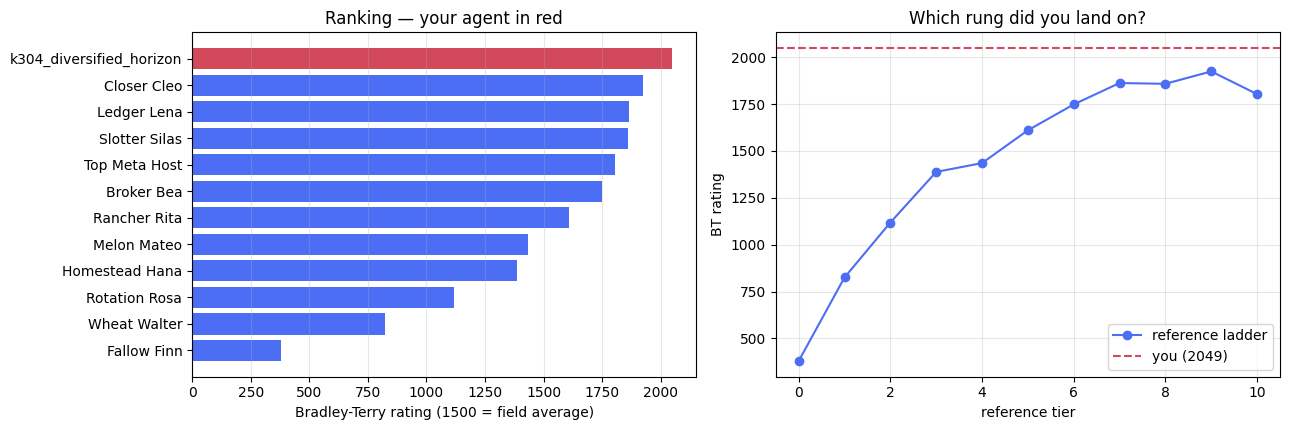

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

colors = ["#d1495b" if s == CHALLENGER_NAME else "#4c6ef5" for s in table.slug]
ax1.barh(table.agent[::-1], table.bt_rating[::-1], color=colors[::-1])
ax1.set_xlabel("Bradley-Terry rating (1500 = field average)")
ax1.set_title("Ranking — your agent in red")
ax1.grid(axis="x", alpha=.3)

ref_rows = table[table.slug != CHALLENGER_NAME].sort_values("tier")
ax2.plot(ref_rows.tier, ref_rows.bt_rating, "-o", color="#4c6ef5", label="reference ladder")
you = table[table.slug == CHALLENGER_NAME]
if len(you):
    ax2.axhline(you.bt_rating.iloc[0], color="#d1495b", ls="--",
                label=f"you ({int(you.bt_rating.iloc[0])})")
ax2.set_xlabel("reference tier"); ax2.set_ylabel("BT rating")
ax2.set_title("Which rung did you land on?")
ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()


---
## 9. Reading the result

Find the highest tier you beat consistently, then look up what that tier does in the
manifest above. The gaps are where your next improvement is.


In [19]:
you_rows = results[(results.agent_a == CHALLENGER_NAME) | (results.agent_b == CHALLENGER_NAME)]
print(f"{CHALLENGER_NAME} vs the ladder\n" + "=" * 58)
beaten = []
for _, r in you_rows.iterrows():
    if r.agent_a == CHALLENGER_NAME:
        opp, my_w, their_w, margin = r.agent_b, r.wins_a, r.wins_b, r.mean_margin_a
    else:
        opp, my_w, their_w, margin = r.agent_a, r.wins_b, r.wins_a, -r.mean_margin_a
    verdict = "WIN " if my_w > their_w else ("tie " if my_w == their_w else "LOSS")
    if my_w > their_w:
        beaten.append(TIER_OF[opp])
    print(f"  {verdict} vs tier {TIER_OF[opp]} {NAME_OF[opp]:<18} "
          f"{my_w}-{their_w}   margin {margin:+,.0f}")

print()
if beaten:
    top = max(beaten)
    top_slug = next(k for k, v in TIER_OF.items() if v == top)
    nxt = manifest[manifest.tier == top + 1]
    print(f"Highest tier beaten: {top} ({NAME_OF[top_slug]})")
    if len(nxt):
        print(f"\nNext rung — tier {top + 1}, {nxt.agent_name.iloc[0]}:")
        print("  " + nxt.headline.iloc[0])
        print("  " + nxt.lesson.iloc[0])
    elif top_meta is not None and top >= TIER_OF[TOP_META_SLUG]:
        print("\nYou beat the top-meta host as well. There is no rung left here --")
        print("raise SEEDS for tighter error bars, then submit.")
    else:
        print("\nYou beat the whole ladder. Time to raise the seed count and submit.")
else:
    print("No wins yet. Start with tier 0 (Fallow Finn) — it literally passes every turn,")
    print("so losing to it means the agent is destroying value: buying seeds it never")
    print("waters, or livestock it never feeds.")


k304_diversified_horizon vs the ladder
  WIN  vs tier 0 Fallow Finn        6-0   margin +153,992
  WIN  vs tier 1 Wheat Walter       6-0   margin +147,406
  WIN  vs tier 2 Rotation Rosa      6-0   margin +137,019
  WIN  vs tier 3 Homestead Hana     6-0   margin +136,430
  WIN  vs tier 4 Melon Mateo        6-0   margin +138,788
  WIN  vs tier 5 Rancher Rita       6-0   margin +115,752
  WIN  vs tier 6 Broker Bea         6-0   margin +21,189
  WIN  vs tier 7 Ledger Lena        6-0   margin +20,872
  WIN  vs tier 8 Slotter Silas      6-0   margin +20,364
  WIN  vs tier 9 Closer Cleo        6-0   margin +30,619
  WIN  vs tier 10 Top Meta Host      6-0   margin +602

Highest tier beaten: 10 (Top Meta Host)

You beat the top-meta host as well. There is no rung left here --
raise SEEDS for tighter error bars, then submit.


### The checklist I actually use

Most of my own broken agents failed one of these, and every one of them is cheap to
check. In rough order of how much money they cost me:

1. **Hire hands.** Four hands cost `1+1+2+3 = 7` coins for a whole day and take you
   from 24 actions to 120. Not hiring is the single most expensive mistake available.
2. **Sell before you buy, in the same turn.** The market queue is processed in list
   order, so a `SELL` placed ahead of a `BUY` funds it immediately. Budget against
   post-sale cash or you will sit at zero coins all season with a full shed.
3. **Feed before you expand.** An animal dies *permanently* after two unfed days.
   Wheat has to be bought before land or livestock, never after.
4. **Do not hoard seeds.** Twenty-five melon seeds is 2,000 coins earning nothing.
   Hold only what you can plant in the next few turns.
5. **Spread your carriers.** One hand with a full sack cannot walk a whole quadrant in
   24 turns. Send several part-loaded hands instead.
6. **Meter premium sales.** Melon, milk, wool and strawberry all floor fast. Check
   `price_curves.csv` before dumping a harvest.
7. **Stop investing near the end.** Coins spent on day 28 never come back, and produce
   still in the shed at the final bell scores exactly nothing — liquidate.
8. **Count what your hands are carrying.** Wheat in a hand's inventory is still yours;
   forget it and you will sell your feed each morning and buy it back at double by
   afternoon.

Two engine details that cost me real time, and that the written rules get wrong:

- The rules say `CARE` banks **+2** per day. The engine adds **+1**
  (`kaggriculture.py`, `_daily_refresh_animals`). Trust the source.
- While only NW is unlocked, `(4, 4)` is the **only** usable shed tile — the other
  three access tiles sit in locked quadrants, and `PICKUP`/`DROP` silently no-op on
  `LOCKED`. Hired hands spawn on those locked tiles and lose a turn walking in.


---
## 10. Turning up the rigour

The default budget (3 seeds, challenger-only) is tuned to be fast enough that you
actually run it. Before trusting a close result, raise it:

```python
SEEDS = list(range(9001, 9021))   # 20 seeds
FULL_ROUND_ROBIN = True           # replay the reference pairings on your seeds too
```

That is 20 seeds x 2 seats x 21 pairings = 840 games, roughly 20 minutes. Worth it when
two candidates are within ~50 BT points, because a 6-game sample cannot separate them.

A few other things worth trying from here:

- **Beat the ladder, then beat yourself.** Add your previous submission as a seventh
  agent — the rung that matters most is your own last version.
- **Check seat bias.** If your agent wins from seat 0 and loses from seat 1, you have a
  market-ordering dependency worth understanding.
- **Watch a game.** `env.render(mode="ipython", width=900, height=700)` after a `play()`
  call is the fastest way to spot a farmer walking in circles.

---

*Reference agents: [kaggriculture-reference-agents](https://www.kaggle.com/datasets/raykkretzschmar/kaggriculture-reference-agents)
(agent code MIT; data and analysis CC BY-SA 4.0; see the dataset's provenance notes).
Measured on `kaggle-environments` 1.32.7. If you find a rung mis-ranked, tell me
in the comments and I will re-measure.*
